In [1]:
import gzip 

import Bio
import Bio.SeqIO

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
datadir = "data/jared_PacBio_data_2"
bin_dir = "data/2D"

In [3]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")
WT_DNA = WT_fasta.seq
WT = WT_DNA.translate()

WT_DNA = WT_fasta.seq
print("WT (in this case the 2D parent)")
print(repr(WT_DNA), repr(WT), sep="\n")

WT (in this case the 2D parent)
Seq('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCA...TGA')
Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*')


In [4]:
sample_info = pd.read_csv(f"{bin_dir}/sample_info.csv")
sample_info

,bin_num,bin_name,category,num_samples,response
0,1,2D-R1-B1,High Hydroxylation,14,3
1,2,2D-R1-B2,Parent Hydroxylation,25,2
2,3,2D-R1-B3,Low Hydroxylation,186,1
3,4,2D-R1-B4,No Hydroxylation,675,0
4,5,2D-R1-B5,High Azidation,16,3
5,6,2D-R1-B6,Parent Azidation,27,2
6,7,2D-R1-B7,Low Azidation,174,1
7,8,2D-R1-B8,No Azidation,683,0


In [5]:
def read_text_file(filename): 
    """Read plain text file"""
    with open(filename, "rt") as fh:
        return [line.strip() for line in fh]

In [6]:
# read in all the sequences from all the bins
# a count the unique sequences (i.e. make histograms)
bin_pd_list = list()
for bin_num in sample_info.bin_num:
    bin_seqs = read_text_file(bin_dir + f"/bin{bin_num}_sequences.txt")
    bin_pd = pd.DataFrame(bin_seqs, columns=["sequence"])
    bin_pd_unique = bin_pd.sequence.value_counts().reset_index()
    bin_pd_unique.columns = ["sequence", "count"]
    bin_pd_unique["bin_num"] = bin_num
    bin_pd_unique = bin_pd_unique.reset_index()
    bin_pd_unique.rename(columns={'index':'seq_idx'}, inplace=True)
    bin_pd_unique["seq_idx"] += 1 # so that we can take log of seq_idx
    bin_pd_list.append(bin_pd_unique)
    
df = pd.concat(bin_pd_list, ignore_index=True)
df["bin_num"] = pd.Categorical(df["bin_num"])
df["is_wt"] = (df.sequence == WT_DNA)

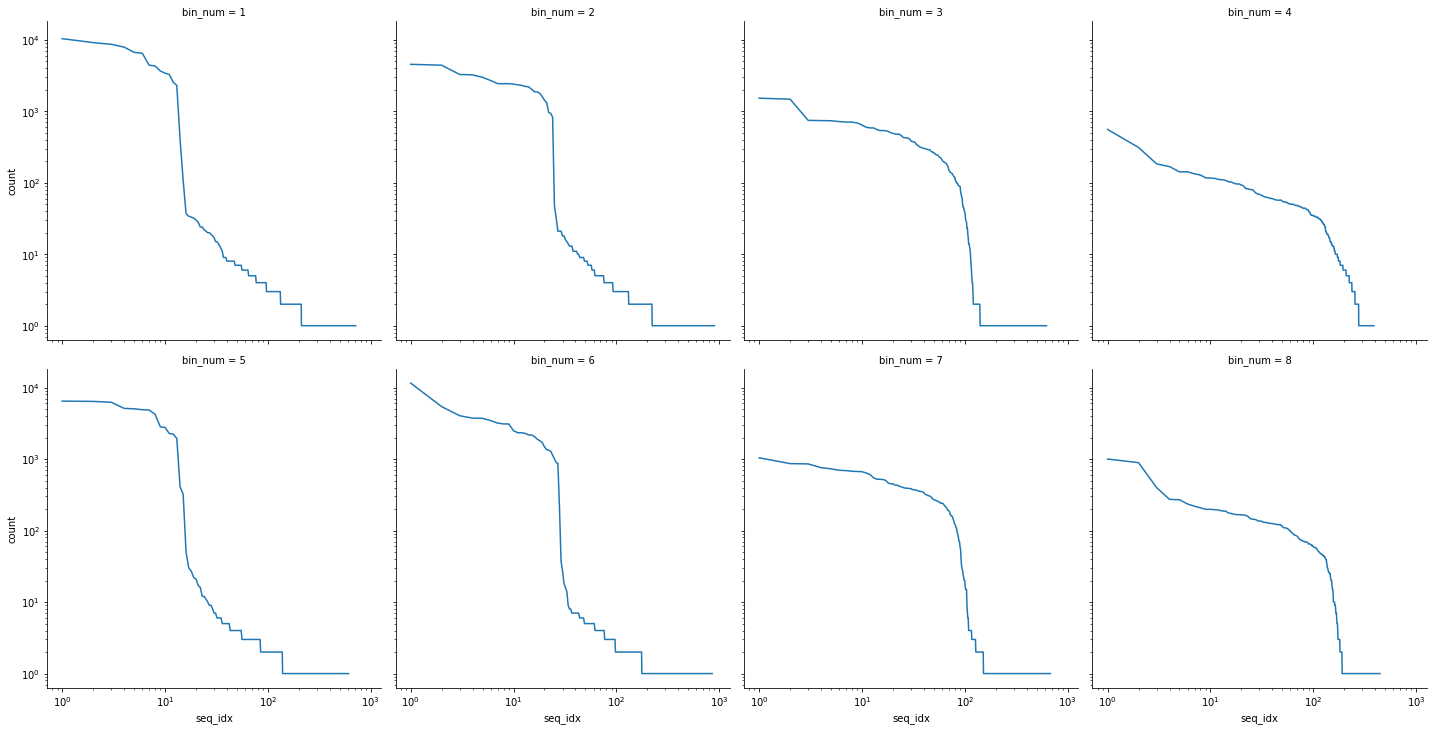

In [7]:
grid = sns.relplot(data=df, y="count", x="seq_idx", col="bin_num", col_wrap=4, kind="line")
grid.set(xscale="log", yscale="log")

In [8]:
sample_info["num_reads"] = np.zeros(len(sample_info), dtype=int)
sample_info["num_unique"] = np.zeros(len(sample_info), dtype=int)
sample_info["WT_rank"] = np.zeros(len(sample_info), dtype=int) * -1
sample_info["WT_pct"] = np.zeros(len(sample_info), dtype=int)

In [9]:
for bin_num, bin_data in df.groupby("bin_num"):
    bin_mask = (sample_info.bin_num == bin_num)
    num_reads = bin_data["count"].sum()
    sample_info.loc[bin_mask, "num_reads"] = num_reads
    sample_info.loc[bin_mask, "num_unique"] = len(bin_data)
    bin_wt = bin_data[bin_data.is_wt == True]
    sample_info.loc[bin_mask, "WT_rank"] = int(bin_wt.seq_idx.item())
    sample_info.loc[bin_mask, "WT_pct"] = int(bin_wt["count"].item() / num_reads * 100)

In [10]:
sample_info

,bin_num,bin_name,category,num_samples,response,num_reads,num_unique,WT_rank,WT_pct
0,1,2D-R1-B1,High Hydroxylation,14,3,74963,714,20,0
1,2,2D-R1-B2,Parent Hydroxylation,25,2,55970,900,1,8
2,3,2D-R1-B3,Low Hydroxylation,186,1,32457,623,36,0
3,4,2D-R1-B4,No Hydroxylation,675,0,9377,388,77,0
4,5,2D-R1-B5,High Azidation,16,3,57018,609,9,4
5,6,2D-R1-B6,Parent Azidation,27,2,73299,855,15,2
6,7,2D-R1-B7,Low Azidation,174,1,31568,680,83,0
7,8,2D-R1-B8,No Azidation,683,0,16263,446,107,0
